# Notebook Projet fil rouge b3 Maury Quentin, Quiatol Evan.

## Importation des données 

In [26]:
# connexion à la base dans le même dossier
import sqlite3
import os
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import ccf

conn = sqlite3.connect("data/meteo_archive_2010_2026.db")

# lire une table
df = pd.read_sql_query("SELECT * FROM hourly_weather", conn)

# afficher le tableau
print(df)

                       date  temperature_2m  weather_code  wind_speed_10m  \
0       2009-12-31 23:00:00        1.104000           3.0       14.145756   
1       2010-01-01 00:00:00        0.954000           3.0       14.759999   
2       2010-01-01 01:00:00        0.754000           3.0       16.520823   
3       2010-01-01 02:00:00        0.554000           3.0       16.099689   
4       2010-01-01 03:00:00        0.454000           3.0       15.391840   
...                     ...             ...           ...             ...   
142962  2026-04-23 17:00:00       20.299999           0.0       15.910410   
142963  2026-04-23 18:00:00       19.049999           0.0       16.077536   
142964  2026-04-23 19:00:00       17.850000           0.0       12.976239   
142965  2026-04-23 20:00:00       17.049999           0.0       11.734564   
142966  2026-04-23 21:00:00       15.550000           0.0       10.692969   

        rain  snowfall  precipitation  wind_speed_100m  snow_depth  \
0    

### Verification des valeurs null 

In [27]:
df.isnull().sum()

date                             0
temperature_2m                   0
weather_code                     0
wind_speed_10m                   0
rain                             0
snowfall                      1103
precipitation                 1103
wind_speed_100m               1103
snow_depth                    1103
apparent_temperature          1103
relative_humidity_2m             0
cloud_cover                      0
wind_direction_10m            1103
soil_temperature_0_to_7cm     1103
surface_pressure              1103
is_day                        1103
sunshine_duration             1103
moyenne_temperature_saison    1103
dtype: int64

#### Création de la colonne température moyenne pour chaque saison

In [28]:
df['date'] = pd.to_datetime(df['date'])

def get_saison_astronomique(date):
    md = date.month * 100 + date.day
    if 320 <= md <= 620: return 'Printemps'
    elif 621 <= md <= 921: return 'Été'
    elif 922 <= md <= 1220: return 'Automne'
    else: return 'Hiver'

df['saison_tmp'] = df['date'].apply(get_saison_astronomique)
df['annee_tmp'] = df['date'].dt.year
mask_fin_decembre = (df['date'].dt.month == 12) & (df['date'].dt.day >= 21)
df.loc[mask_fin_decembre, 'annee_tmp'] += 1

df['moyenne_temperature_saison'] = df.groupby(['annee_tmp', 'saison_tmp'])['temperature_2m'].transform('mean')
colonnes_a_virer = ['saison_tmp', 'annee_tmp', 'annee', 'annee_pour_saison']
df = df.drop(columns=[c for c in colonnes_a_virer if c in df.columns])

# sauvegarde
df.to_sql("hourly_weather", conn, if_exists='replace', index=False)

print("Base de données nettoyée et mise à jour !")
print(df.head())

Base de données nettoyée et mise à jour !
                 date  temperature_2m  weather_code  wind_speed_10m  rain  \
0 2009-12-31 23:00:00           1.104           3.0       14.145756   0.0   
1 2010-01-01 00:00:00           0.954           3.0       14.759999   0.0   
2 2010-01-01 01:00:00           0.754           3.0       16.520823   0.0   
3 2010-01-01 02:00:00           0.554           3.0       16.099689   0.0   
4 2010-01-01 03:00:00           0.454           3.0       15.391840   0.0   

   snowfall  precipitation  wind_speed_100m  snow_depth  apparent_temperature  \
0       0.0            0.0        20.620806         0.0             -3.261446   
1       0.0            0.0        21.915693         0.0             -3.543432   
2       0.0            0.0        24.365910         0.0             -4.041818   
3       0.0            0.0        23.936617         0.0             -4.207702   
4       0.0            0.0        23.233253         0.0             -4.238064   

   relat

## Visualisation

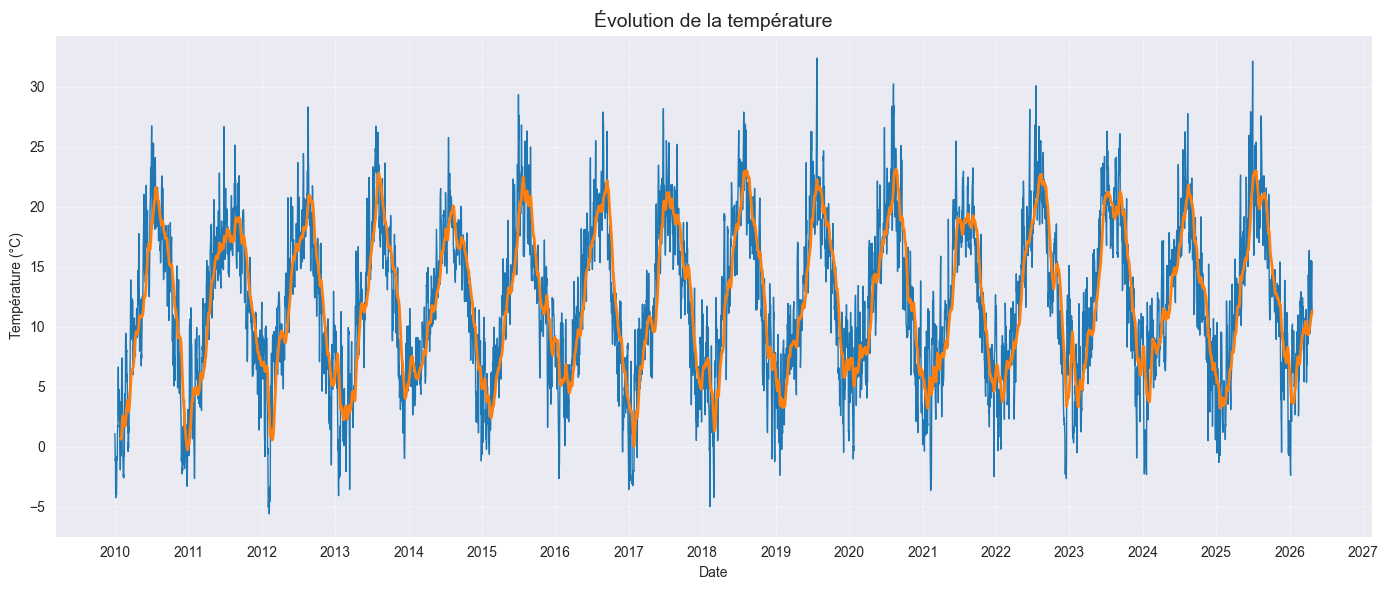

In [29]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# moyenne journalière pour réduire le bruit
df_daily = df.set_index('date').resample('D').mean()

plt.figure(figsize=(14,6))

plt.plot(
    df_daily.index,
    df_daily['temperature_2m'],
    linewidth=1
)

# moyenne glissante (30 jours)
rolling = df_daily['temperature_2m'].rolling(30).mean()
plt.plot(df_daily.index, rolling, linewidth=2)

plt.title("Évolution de la température", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Température (°C)")

# axe temporel lisible
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Le graphique ci-dessus n'est pas très lisible, donc nous allons prendre une range d'une semaine pour faire une meilleure visualisation de l'évolution de la température dans le temps.

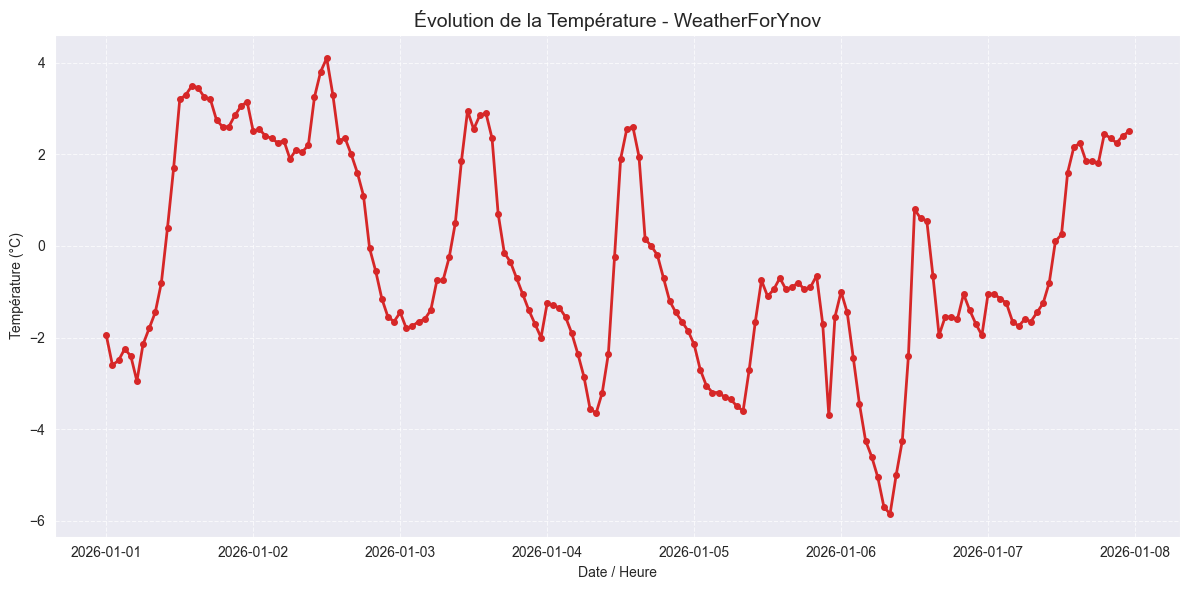

In [30]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.figure(figsize=(12, 6))
plt.plot(
    df_filtered['date'],
    df_filtered['temperature_2m'],
    color='tab:red',
    linewidth=2,
    marker='o',
    markersize=4
)
plt.title('Évolution de la Température - WeatherForYnov', fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nous pouvons observer qu'il y a une chute des températures pendant la nuit et qu'il y a une certaine continuité entre les jours.

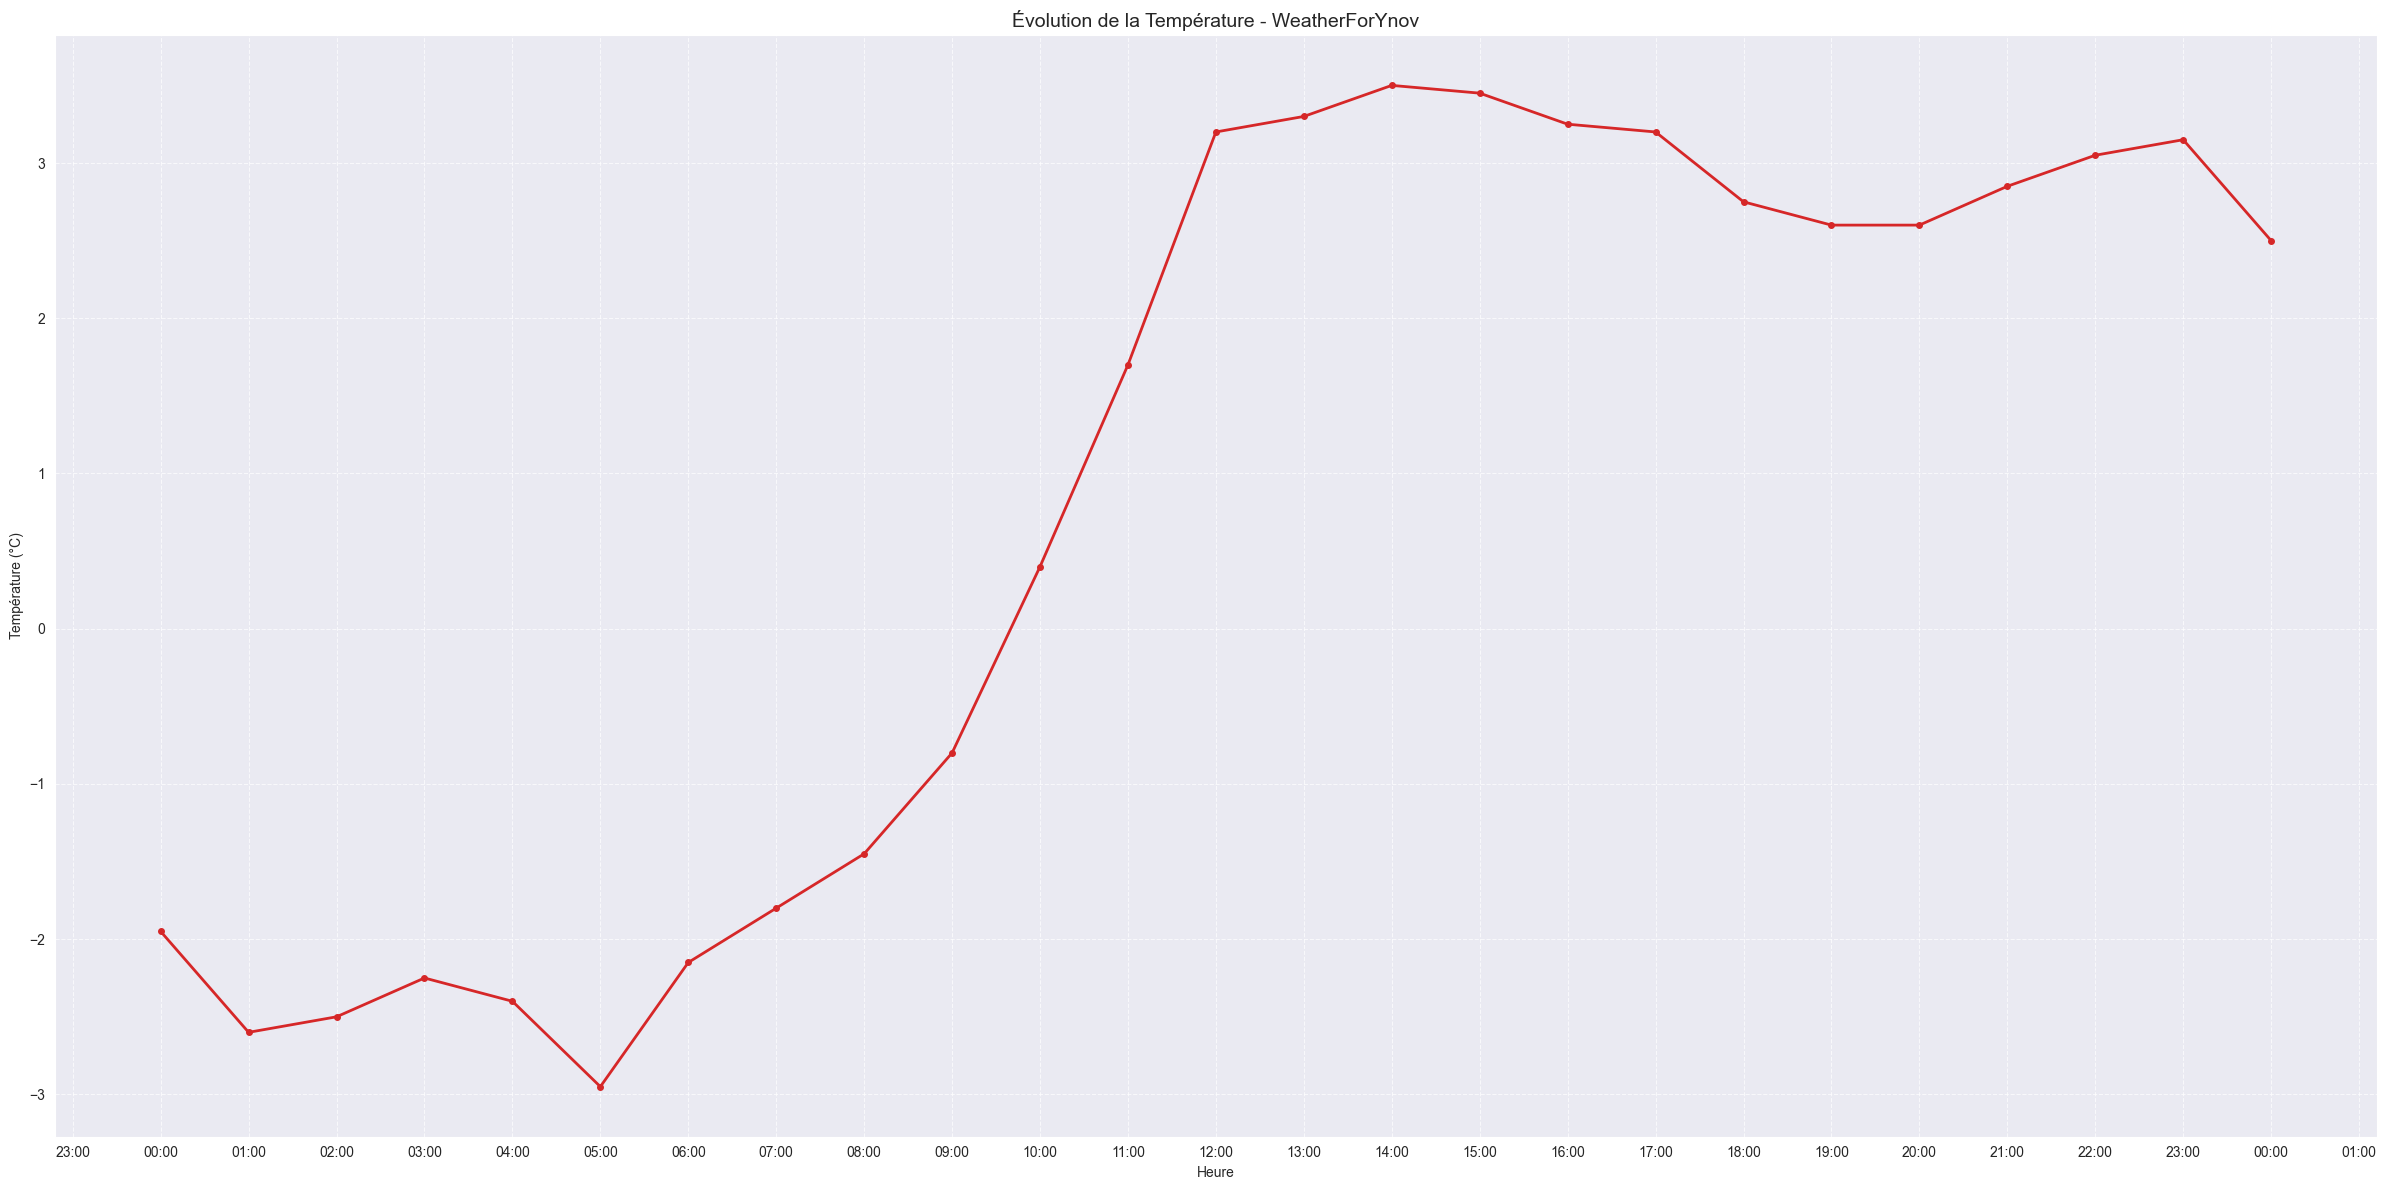

In [31]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-02 00:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.figure(figsize=(24,12))
plt.plot(df_filtered['date'], df_filtered['temperature_2m'], color='tab:red', linewidth=2, marker='o', markersize=4)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.title('Évolution de la Température - WeatherForYnov', fontsize=14)
plt.xlabel('Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ce graphique ici confirme que la température est plus basse la nuit.

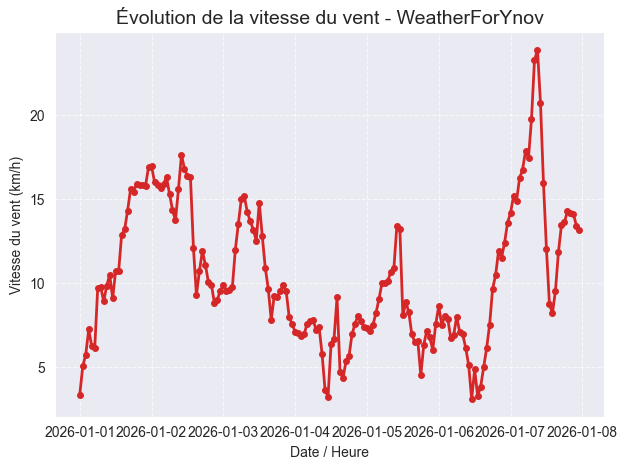

In [32]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.Figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['wind_speed_10m'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title('Évolution de la vitesse du vent - WeatherForYnov', fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Vitesse du vent (km/h)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

On peut observer que la vitesse du vent est étroitement corrélé avec la température. Cependant, on ne peut pas affirmer à 100% qu'ils sont corrélées

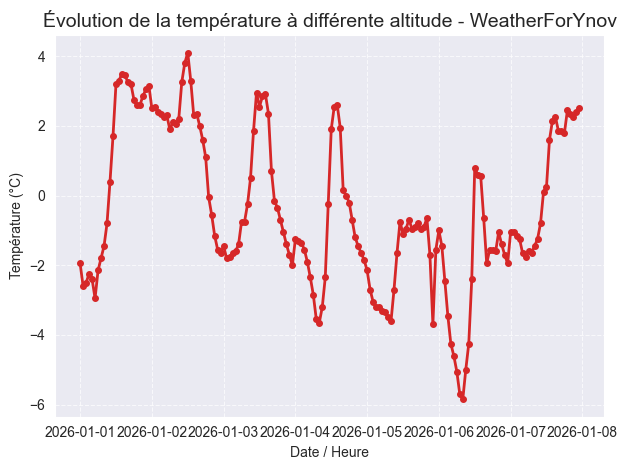

In [33]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

start_date = pd.Timestamp("2026-01-01 00:00:00")
end_date = pd.Timestamp("2026-01-07 23:00:00")

mask = (df['date'] >= start_date) & (df['date'] <= end_date)
df_filtered = df.loc[mask]

plt.Figure(figsize=(12,6))
plt.plot(df_filtered['date'], df_filtered['temperature_2m'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title("Évolution de la température à différente altitude - WeatherForYnov", fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

On peut remarquer que les températures à différentes altitudes semblent très liés

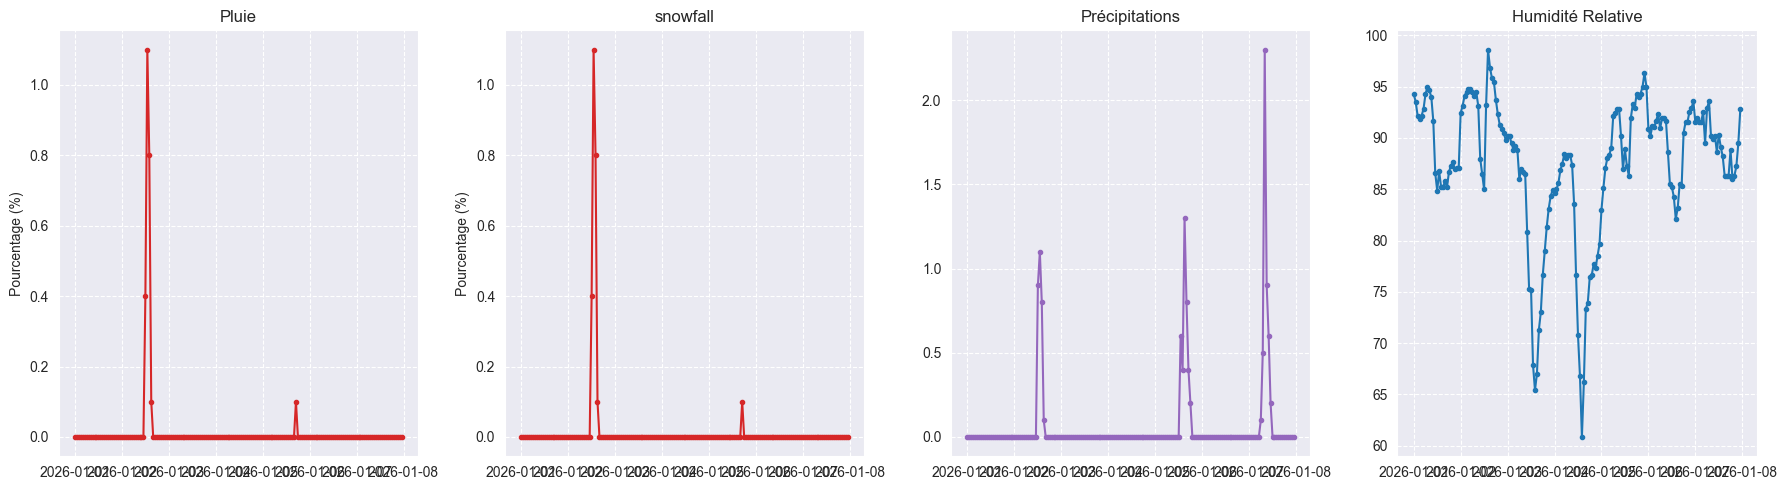

In [34]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 5))

# Graphique 1 : Rain (Pluie)
ax1.plot(df_filtered['date'], df_filtered['rain'], color='tab:red', marker='o', markersize=3)
ax1.set_title('Pluie')
ax1.set_ylabel('Pourcentage (%)')
ax1.grid(True, linestyle='--')

# Graphique 2 : Snowfall (Neige)
ax2.plot(df_filtered['date'], df_filtered['rain'], color='tab:red', marker='o', markersize=3)
ax2.set_title('snowfall')
ax2.set_ylabel('Pourcentage (%)')
ax2.grid(True, linestyle='--')

# Graphique 3 : Précipitations
ax3.plot(df_filtered['date'], df_filtered['precipitation'], color='tab:purple', marker='o', markersize=3)
ax3.set_title('Précipitations')
ax3.grid(True, linestyle='--')

# Graphique 4 : Humidité
ax4.plot(df_filtered['date'], df_filtered['relative_humidity_2m'], color='tab:blue', marker='o', markersize=3)
ax4.set_title('Humidité Relative')
ax4.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

On peut remarquer que la pluie et les précipitations sont liés, cependant, on remarque quand même qu'il y a un facteur de plus qui rentre en compte pour les précipitations, au vu des températures, on pourrait déduire que c'est de la neige. On peut remarquer que la pluie est très peu significative sur la valeur de l'humidité. Néanmoins, on sait qu'il a neigé et que le taux d'humidité est étroitement lié aux faites que la neige a fondu.

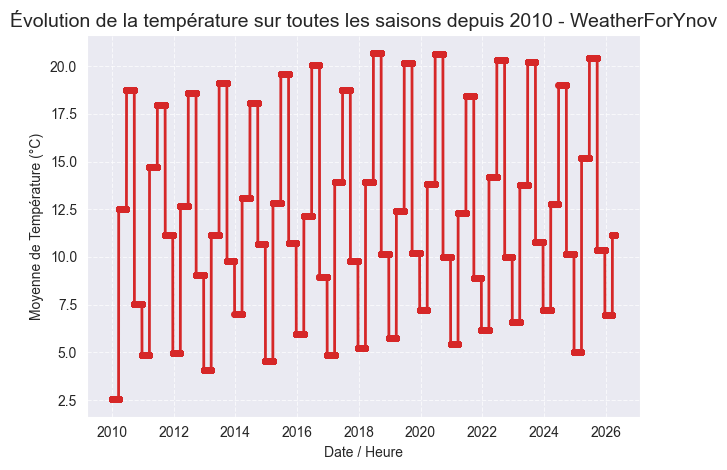

In [35]:
plt.Figure(figsize=(12,6))
plt.plot(df['date'], df['moyenne_temperature_saison'], color='tab:red', linewidth=2, marker='o', markersize=4)
plt.title("Évolution de la température sur toutes les saisons depuis 2010 - WeatherForYnov", fontsize=14)
plt.xlabel('Date / Heure')
plt.ylabel('Moyenne de Température (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [36]:
correlation = df.corr()

print(correlation)

                                date  temperature_2m  weather_code  \
date                        1.000000        0.057452      0.029040   
temperature_2m              0.057452        1.000000     -0.014041   
weather_code                0.029040       -0.014041      1.000000   
wind_speed_10m             -0.021046       -0.032511      0.238695   
rain                        0.032901        0.025162      0.583744   
snowfall                   -0.013651       -0.084163      0.169249   
precipitation               0.032562        0.016162      0.597004   
wind_speed_100m            -0.003693       -0.158039      0.209951   
snow_depth                 -0.106834       -0.226691      0.053033   
apparent_temperature        0.062632        0.988356     -0.022360   
relative_humidity_2m       -0.008248       -0.606066      0.191573   
cloud_cover                -0.021095       -0.069109      0.345316   
wind_direction_10m          0.002314        0.033438      0.096633   
soil_temperature_0_t

On peut observer que dans cette matrice de corrélation, nous avons quelques valeurs qui ont des corrélations. Cependant ces valeurs sont de la même famille "températures à 2m; températures à 20m; températures à 50m" ou alors "pluies; intempéries", mais ces valeurs sont liées par un instant T.

In [37]:
df_shifted = df.shift(-1)

corr = df_shifted.corrwith(df["temperature_2m"])

print(corr)

date                         -0.000962
temperature_2m                0.991843
weather_code                 -0.011407
wind_speed_10m               -0.036414
rain                          0.034874
snowfall                     -0.084148
precipitation                 0.025760
wind_speed_100m              -0.143088
snow_depth                   -0.227577
apparent_temperature          0.980823
relative_humidity_2m         -0.594084
cloud_cover                  -0.075183
wind_direction_10m            0.038215
soil_temperature_0_to_7cm     0.976157
surface_pressure             -0.082394
is_day                        0.289839
sunshine_duration             0.365733
moyenne_temperature_saison    0.726420
dtype: float64


On peut voir une forte correlation entre la temperature au moment T0 et le moment T1 

In [38]:
df_shifted = df.shift(-24)

corr = df_shifted.corrwith(df["temperature_2m"])

print(corr)

date                         -0.005781
temperature_2m                0.924766
weather_code                 -0.010663
wind_speed_10m               -0.058593
rain                          0.038565
snowfall                     -0.079339
precipitation                 0.029928
wind_speed_100m              -0.188106
snow_depth                   -0.235544
apparent_temperature          0.918507
relative_humidity_2m         -0.559825
cloud_cover                  -0.101178
wind_direction_10m            0.062942
soil_temperature_0_to_7cm     0.944540
surface_pressure             -0.063109
is_day                        0.347273
sunshine_duration             0.401192
moyenne_temperature_saison    0.726252
dtype: float64


On peut observer que la correlation entre la temperature T0 et T1 a baisser.

In [39]:
if 'heure' not in df.columns:
    df['heure'] = df['date'].dt.hour
if 'mois' not in df.columns:
    df['mois']  = df['date'].dt.month

PALETTE_SAISONS = {
    'Printemps': '#639922',
    'Été':       '#BA7517',
    'Automne':   '#D85A30',
    'Hiver':     '#185FA5',
}
MOIS_LABELS = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

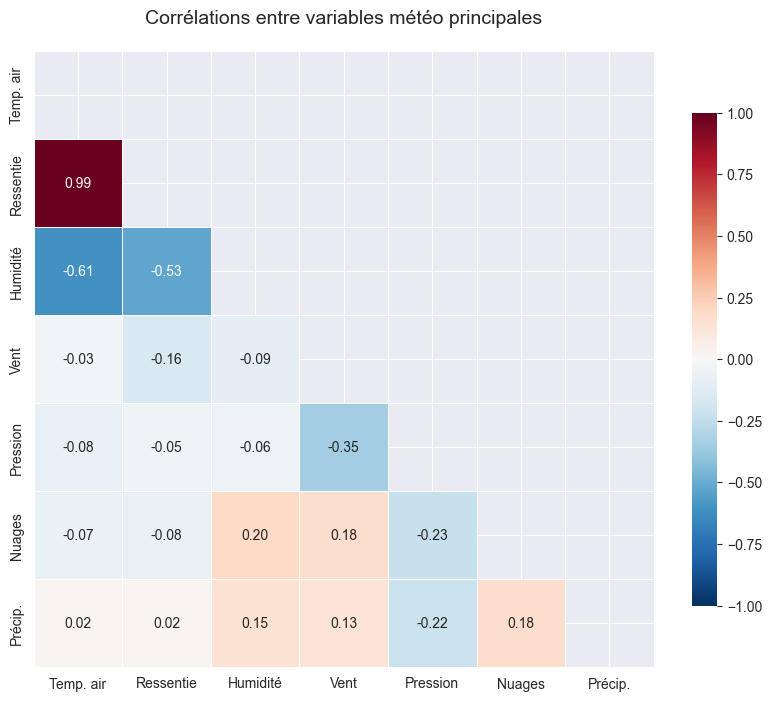

In [40]:
plt.figure(figsize=(10, 8))

cols_corr = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'wind_speed_10m', 'surface_pressure', 'cloud_cover',
    'precipitation'
]

labels_fr = ['Temp. air', 'Ressentie', 'Humidité', 'Vent', 'Pression', 'Nuages', 'Précip.']

corr = df[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', xticklabels=labels_fr, yticklabels=labels_fr,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Corrélations entre variables météo principales', fontsize=14, pad=20)
plt.show()

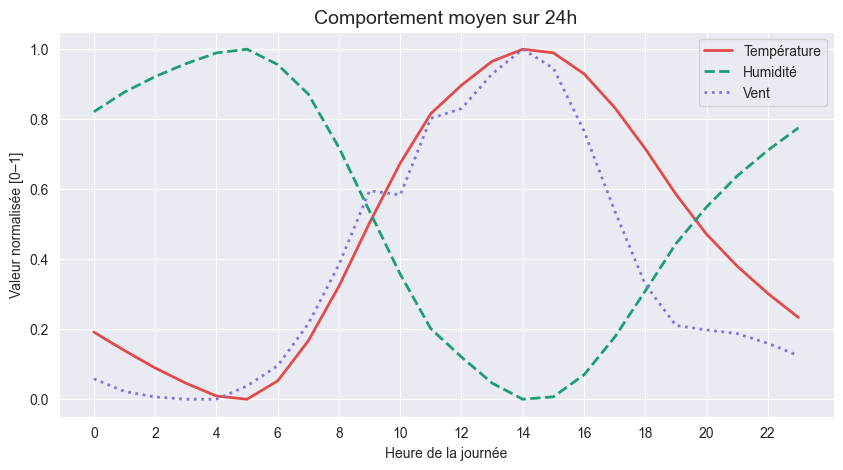

In [41]:
plt.figure(figsize=(10, 5))
profil = df.groupby('heure').agg(
    temp     = ('temperature_2m',       'mean'),
    humidite = ('relative_humidity_2m', 'mean'),
    vent     = ('wind_speed_10m',        'mean'),
).reset_index()

def norm(s): return (s - s.min()) / (s.max() - s.min())

plt.plot(profil['heure'], norm(profil['temp']), color='#E24B4A', lw=2, label='Température')
plt.plot(profil['heure'], norm(profil['humidite']), color='#1D9E75', lw=2, linestyle='--', label='Humidité')
plt.plot(profil['heure'], norm(profil['vent']), color='#7F77DD', lw=2, linestyle=':', label='Vent')

plt.xlabel('Heure de la journée')
plt.ylabel('Valeur normalisée [0–1]')
plt.title('Comportement moyen sur 24h', fontsize=14)
plt.xticks(range(0, 24, 2))
plt.legend()
plt.show()

In [42]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

df_clean = df.dropna()

target_col = 'temperature_2m'
features = df_clean.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')

KeyboardInterrupt: 

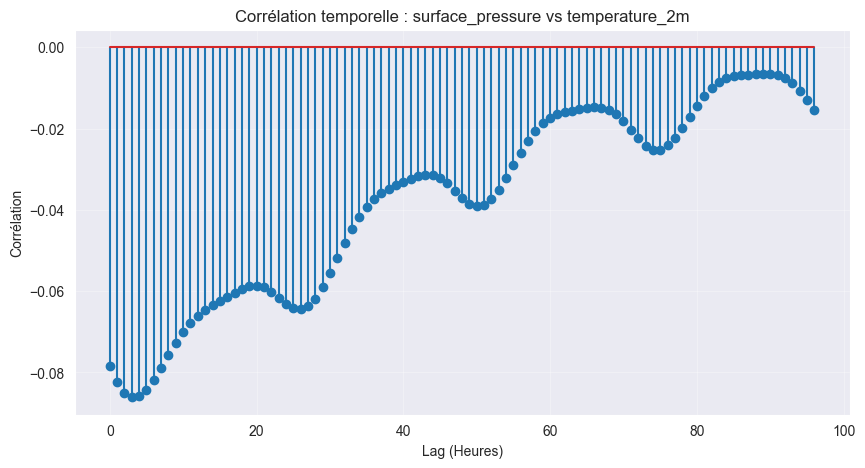

In [43]:
other_var = 'surface_pressure'
lags = np.arange(-48, 49)

if other_var in df_clean.columns:
    ccf_vals = ccf(df_clean[other_var], df_clean[target_col], adjusted=False)[:len(lags)]

    plt.figure(figsize=(10, 5))
    plt.stem(range(len(ccf_vals)), ccf_vals)
    plt.title(f"Corrélation temporelle : {other_var} vs {target_col}")
    plt.xlabel("Lag (Heures)")
    plt.ylabel("Corrélation")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

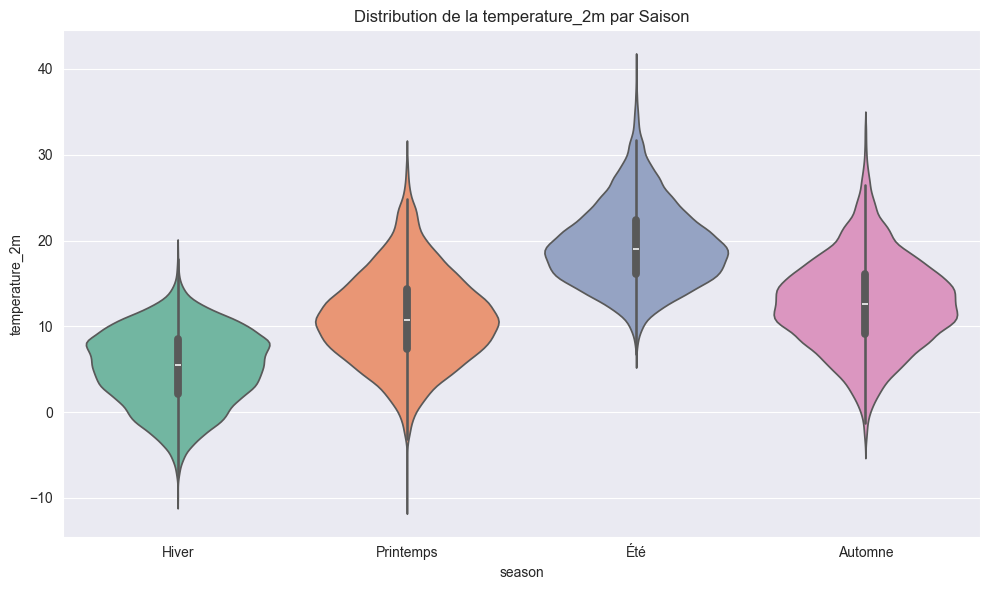

In [44]:
df_visu = df_clean.copy()
df_visu['season'] = (df_visu.index.month % 12 + 3) // 3

plt.figure(figsize=(10, 6))
sns.violinplot(x='season', y=target_col, data=df_visu, palette='Set2', hue='season', legend=False)
plt.xticks([0, 1, 2, 3], ['Hiver', 'Printemps', 'Été', 'Automne'])
plt.title(f"Distribution de la {target_col} par Saison")
plt.tight_layout()
plt.show()

In [45]:
if not isinstance(df.index, pd.DatetimeIndex):
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

df['heure'] = df.index.hour
df['jour_semaine'] = df.index.dayofweek
df['mois'] = df.index.month
df['jour_annee'] = df.index.dayofyear

df['heure_sin'] = np.sin(2 * np.pi * df['heure'] / 24)
df['heure_cos'] = np.cos(2 * np.pi * df['heure'] / 24)

df['mois_sin'] = np.sin(2 * np.pi * df['mois'] / 12)
df['mois_cos'] = np.cos(2 * np.pi * df['mois'] / 12)

df[['heure', 'heure_sin', 'heure_cos', 'mois_sin', 'mois_cos']].head()

,heure,heure_sin,heure_cos,mois_sin,mois_cos
date,,,,,
2009-12-31 23:00:00,23,-0.258819,0.965926,-2.449294e-16,1.000000
2010-01-01 00:00:00,0,0.000000,1.000000,5.000000e-01,0.866025
2010-01-01 01:00:00,1,0.258819,0.965926,5.000000e-01,0.866025
2010-01-01 02:00:00,2,0.500000,0.866025,5.000000e-01,0.866025
2010-01-01 03:00:00,3,0.707107,0.707107,5.000000e-01,0.866025


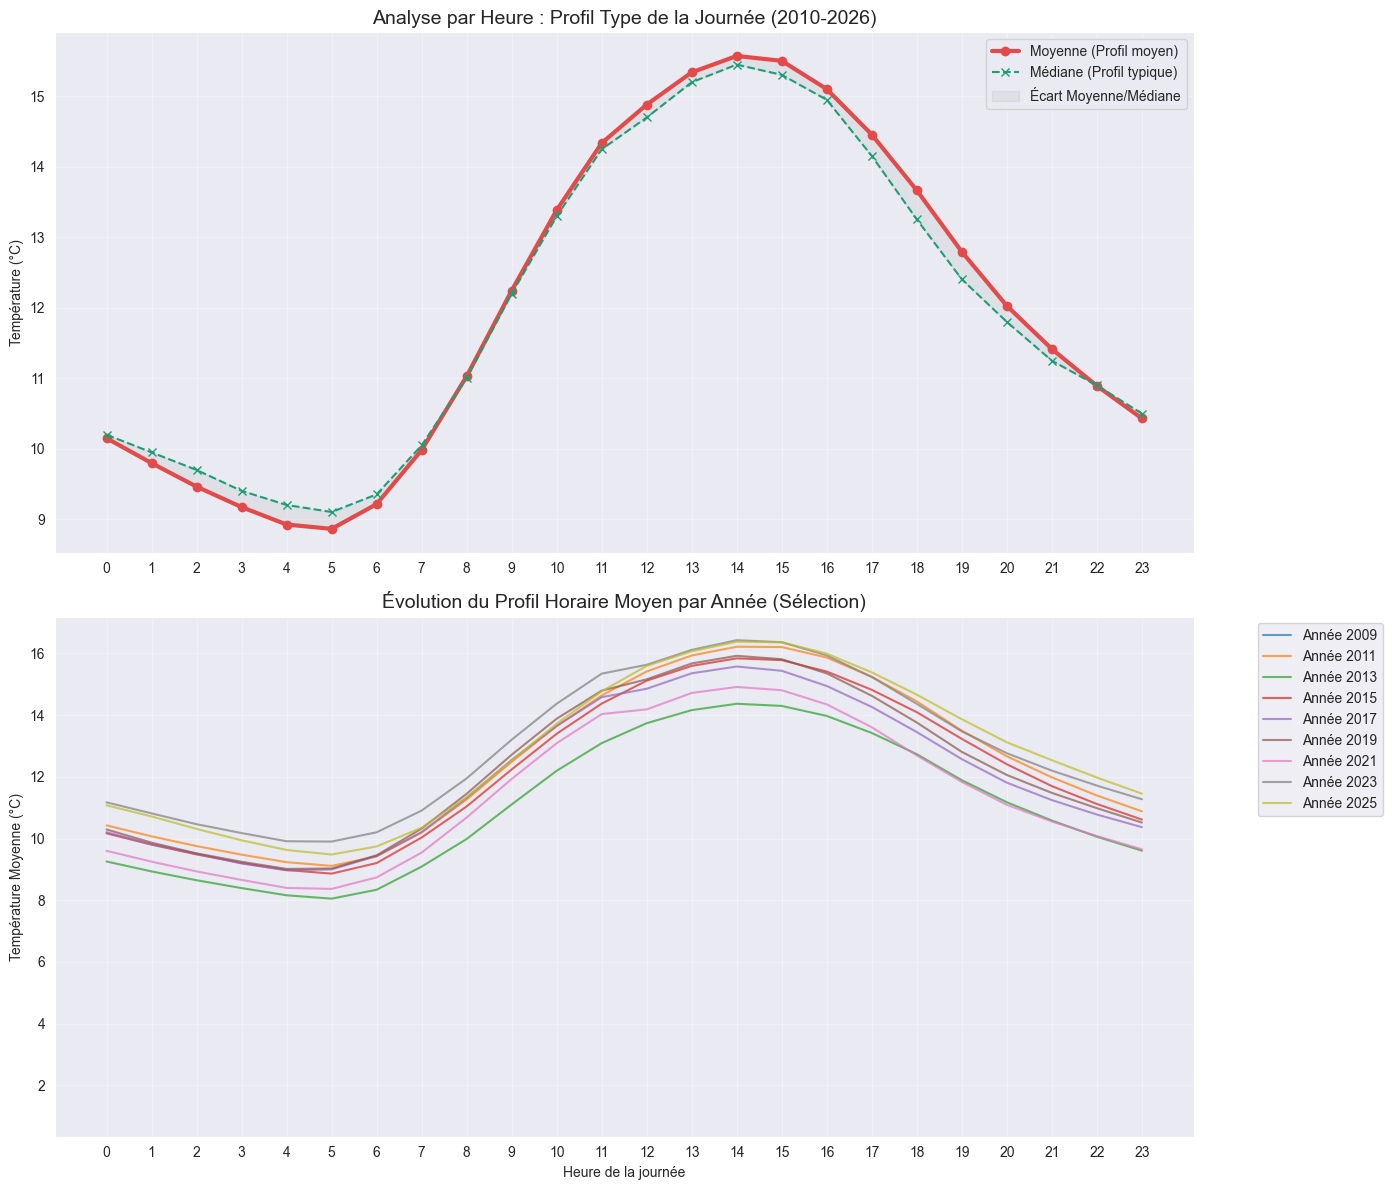

In [46]:
moyenne_globale = df['temperature_2m'].mean()
mediane_globale = df['temperature_2m'].median()

if 'heure' not in df.columns:
    df['heure'] = df.index.hour
if 'annee' not in df.columns:
    df['annee'] = df.index.year

stats_horaires = df.groupby('heure')['temperature_2m'].agg(['mean', 'median']).reset_index()
stats_annuelles = df.groupby(['annee', 'heure'])['temperature_2m'].mean().reset_index()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

ax1.plot(stats_horaires['heure'], stats_horaires['mean'], label='Moyenne (Profil moyen)', color='#E24B4A', marker='o', lw=3)
ax1.plot(stats_horaires['heure'], stats_horaires['median'], label='Médiane (Profil typique)', color='#1D9E75', linestyle='--', marker='x')
ax1.fill_between(stats_horaires['heure'], stats_horaires['mean'], stats_horaires['median'], color='gray', alpha=0.1, label='Écart Moyenne/Médiane')
ax1.set_title('Analyse par Heure : Profil Type de la Journée (2010-2026)', fontsize=14)
ax1.set_ylabel('Température (°C)')
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)
ax1.legend()

annees_selectionnees = sorted(df['annee'].unique())[::2]
for annee in annees_selectionnees:
    data_annee = stats_annuelles[stats_annuelles['annee'] == annee]
    ax2.plot(data_annee['heure'], data_annee['temperature_2m'], label=f'Année {annee}', alpha=0.7)

ax2.set_title('Évolution du Profil Horaire Moyen par Année (Sélection)', fontsize=14)
ax2.set_xlabel('Heure de la journée')
ax2.set_ylabel('Température Moyenne (°C)')
ax2.set_xticks(range(0, 24))
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
chemin_react_data = r"C:\Users\quiat\WebstormProjects\tableau-de-bord-meteo\src\data"
os.makedirs(chemin_react_data, exist_ok=True)
profil.to_json(os.path.join(chemin_react_data, "hourly_profile.json"), orient="records")
print("Export terminé avec succès vers ton projet Webstorm !")